# MVP - Mapa de Calor de Entregas (Vitória - ES)

## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap

## 2. Simulação de Dados

Coordenadas fixadas em **áreas urbanas densas** de Vitória - ES, sem matas nem água.

| Zona | Bairro | Característica |
|------|--------|----------------|
| A | Jardim da Penha | Bairro residencial/comercial denso, nordeste da ilha |
| B | Praia do Canto / Enseada do Suá | Área nobre com alta densidade residencial |
| C | Bento Ferreira / Santa Lúcia | Bairros centrais com muitas farmácias e comércios |



In [2]:
np.random.seed(42)
n_pedidos = 300
zonas = [
    # Jardim da Penha: miolo do bairro, longe da praia e do manguezal
    {"lat": -20.2810, "lon": -40.3020, "std": 0.0018, "peso": 0.40},
    # Praia do Canto / Enseada do Suá: interior das quadras, longe da orla
    {"lat": -20.3000, "lon": -40.2980, "std": 0.0015, "peso": 0.30},
    # Bento Ferreira / Santa Lúcia: centro residencial, sem matas
    {"lat": -20.3060, "lon": -40.3180, "std": 0.0018, "peso": 0.30},
]

latitudes  = np.concatenate([np.random.normal(z["lat"], z["std"], int(n_pedidos * z["peso"])) for z in zonas])
longitudes = np.concatenate([np.random.normal(z["lon"], z["std"], int(n_pedidos * z["peso"])) for z in zonas])

df_pedidos = pd.DataFrame({
    'pedido_id'     : range(1, n_pedidos + 1),
    'latitude'      : latitudes,
    'longitude'     : longitudes,
    'valor_entrega' : np.random.uniform(7.00, 18.00, n_pedidos)
})

print(f"Total de pedidos: {len(df_pedidos)}")
print(f"Lat: {latitudes.min():.4f} → {latitudes.max():.4f}")
print(f"Lon: {longitudes.min():.4f} → {longitudes.max():.4f}")
df_pedidos.head()

Total de pedidos: 300
Lat: -20.3118 → -20.2766
Lon: -40.3224 → -40.2934


,pedido_id,latitude,longitude,valor_entrega
0,1,-20.280106,-40.303492,9.521765
1,2,-20.281249,-40.303008,14.944778
2,3,-20.279834,-40.300655,14.920402
3,4,-20.278259,-40.300901,14.052624
4,5,-20.281421,-40.302038,14.633433


## 3. Validação do Número de Clusters (Elbow Method + Silhouette Score)

Antes de aplicar o K-Means com `n_clusters=3`, é importante validar estatisticamente se essa é, de fato, a melhor escolha. Para isso, usamos duas métricas complementares:

- **Elbow Method (Método do Cotovelo):** observa a inércia (soma das distâncias quadradas dentro dos clusters) para diferentes valores de k. O "cotovelo" do gráfico indica o ponto de retorno decrescente, onde adicionar mais clusters deixa de trazer ganho significativo.
- **Silhouette Score:** mede o quão bem separados e coesos estão os clusters, variando de -1 (ruim) a 1 (ótimo).

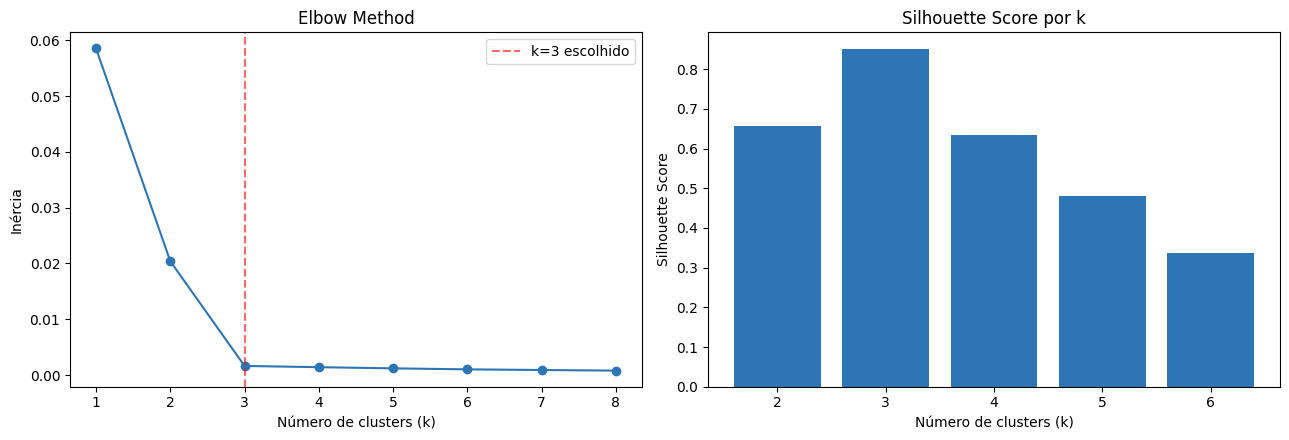

Silhouette Score por k:
  k=2: 0.6564
  k=3: 0.8505  ← maior score
  k=4: 0.6342
  k=5: 0.4800
  k=6: 0.3376


In [3]:
X = df_pedidos[['latitude', 'longitude']]

# Elbow Method
inertias = []
k_range = range(1, 9)
for k in k_range:
    km_teste = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km_teste.inertia_)

# Silhouette Score (só faz sentido para k >= 2)
silhouette_scores = {}
for k in range(2, 7):
    km_teste = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    silhouette_scores[k] = silhouette_score(X, km_teste.labels_)

# Plot lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(k_range), inertias, marker='o', color='#2E75B6')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inércia')
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='k=3 escolhido')
axes[0].legend()

axes[1].bar(list(silhouette_scores.keys()), list(silhouette_scores.values()), color='#2E75B6')
axes[1].set_title('Silhouette Score por k')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

print("Silhouette Score por k:")
for k, score in silhouette_scores.items():
    marca = "  ← maior score" if score == max(silhouette_scores.values()) else ""
    print(f"  k={k}: {score:.4f}{marca}")

**Conclusão da validação:** o gráfico do Elbow Method mostra uma queda acentuada da inércia até k=3, suavizando-se a partir daí — o "cotovelo" da curva. O Silhouette Score confirma essa escolha: k=3 obtém a maior pontuação entre todos os valores testados, indicando clusters bem separados e coesos. Isso valida estatisticamente a decisão de usar `n_clusters=3`, alinhada também com a divisão geográfica natural em três bairros-alvo (Jardim da Penha, Praia do Canto/Enseada do Suá e Bento Ferreira/Santa Lúcia).

## 4. Machine Learning: Identificação de Hotspots (K-Means)

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X)
df_pedidos['cluster_hotspot'] = kmeans.labels_

hotspots_centros  = kmeans.cluster_centers_
contagem_cluster  = df_pedidos['cluster_hotspot'].value_counts().sort_index()

print("Hotspots detectados:")
for i, c in enumerate(hotspots_centros):
    print(f"  Hotspot {i+1}: ({c[0]:.4f}, {c[1]:.4f})  |  {contagem_cluster[i]} pedidos")

Hotspots detectados:
  Hotspot 1: (-20.2811, -40.3019)  |  120 pedidos
  Hotspot 2: (-20.3060, -40.3182)  |  90 pedidos
  Hotspot 3: (-20.2999, -40.2981)  |  90 pedidos


## 5. Faturamento Estimado por Hotspot

O campo `valor_entrega`, gerado na simulação de dados, é utilizado aqui para estimar o faturamento agregado por região (cluster). Essa análise agrega valor de negócio à identificação geográfica dos hotspots, permitindo priorizar regiões não só por volume de pedidos, mas também por retorno financeiro.

In [5]:
faturamento_cluster = df_pedidos.groupby('cluster_hotspot')['valor_entrega'].agg(
    faturamento_total='sum',
    ticket_medio='mean',
    qtd_pedidos='count'
).round(2)

nomes_zonas = ["Jardim da Penha", "Praia do Canto / Enseada do Suá", "Bento Ferreira / Santa Lúcia"]
faturamento_cluster.index = [nomes_zonas[i] for i in faturamento_cluster.index]
faturamento_cluster = faturamento_cluster.sort_values('faturamento_total', ascending=False)

print("Faturamento estimado por hotspot:")
faturamento_cluster

Faturamento estimado por hotspot:


,faturamento_total,ticket_medio,qtd_pedidos
Jardim da Penha,1475.56,12.30,120
Praia do Canto / Enseada do Suá,1161.35,12.90,90
Bento Ferreira / Santa Lúcia,1080.55,12.01,90


## 6. Mapa de Calor Interativo — Módulo do Entregador

In [6]:
# Centro do mapa: ponto médio entre os bairros urbanos usados
mapa_vitoria = folium.Map(
    location=[-20.2950, -40.3060],
    zoom_start=14,
    tiles="OpenStreetMap"
)

# HeatMap
dados_calor = df_pedidos[['latitude', 'longitude']].values.tolist()
HeatMap(
    dados_calor,
    radius=22,
    blur=14,
    min_opacity=0.45,
    max_zoom=16,
    gradient={0.2: 'blue', 0.45: 'lime', 0.75: 'orange', 1.0: 'red'}
).add_to(mapa_vitoria)

# Marcadores dos hotspots
cores       = ["red", "blue", "green"]
nomes_zonas = ["Jardim da Penha", "Praia do Canto / Enseada do Suá", "Bento Ferreira / Santa Lúcia"]

for i, centro in enumerate(hotspots_centros):
    faturamento_zona = faturamento_cluster.loc[nomes_zonas[i], 'faturamento_total']
    folium.Marker(
        location=[centro[0], centro[1]],
        popup=folium.Popup(
            f"<b>🔥 Hotspot {i+1} — {nomes_zonas[i]}</b><br>"
            f"📦 Pedidos na área: {contagem_cluster[i]}<br>"
            f"💰 Faturamento estimado: R$ {faturamento_zona:.2f}<br>"
            f"📍 ({centro[0]:.4f}, {centro[1]:.4f})",
            max_width=280
        ),
        tooltip=f"Hotspot {i+1}: {nomes_zonas[i]}",
        icon=folium.Icon(color=cores[i], icon="fire", prefix="fa")
    ).add_to(mapa_vitoria)

folium.LayerControl().add_to(mapa_vitoria)
mapa_vitoria

## 7. Exportar Mapa como HTML

In [7]:
mapa_vitoria.save("mapa_de_calor_entregador.html")
print("MVP Gerado: 'mapa_de_calor_entregador.html' salvo com sucesso!")

MVP Gerado: 'mapa_de_calor_entregador.html' salvo com sucesso!
